# **Model Boundary Saturation Studies**

Whether it's for galaxies or stars, we observe saturation of the boundaries of the models when computing physical parameters of observed sources. As an instance, while for galaxies some sources stack at the lower/upper limit in Z, stars saturate at the limits in Teff, logg or Fe/H. Even if the physics is not the same in these two cases, the results behave similarly.

In this notebook we investigate this effect with three ideas in mind:
 - The cause of this behavior could be a bug in the code.
 - The cause of this behavior could be a physical effect, probably related to the errors.
 - A combination of both, where this behavior only happend in a specific setup of the obseved magnitude.$

We work with mag_dm substracted to observed magnitude, to make appear clearly the systematics of the scale factor.

## **0. Initialisation**

In [159]:
### Libs ###
from imports import *

#custom
from src.download_bt_spectra import download_bt_spectra
import src.data_manipulations as dm; reload(dm)
import src.plot_tools as pt; reload(pt)
import src.photometry_errors as pe; reload(pe)
from src.format_to_dat import format_to_lephareinput 

#lephare
import lephare as lp; reload(lp)
config = lp.default_stargal_config.copy()

base_dir = os.path.abspath(os.path.join(os.getcwd()))
sys.path.append(base_dir)

%matplotlib inline

User defined LEPHAREDIR is set. Code runs depend on all required
auxiliary data being present at /home/hallouin/.cache/lephare/data.
User defined LEPHAREWORK is set. All intermediate files will be written to:
 /home/hallouin/.cache/lephare/work


## **1. Prepare Model**

### 1.1 Prepare SEDs

In [160]:
#--- Physical quantities of the model ---
#WARNING: The number of seds downloaded is equal to len(teff_values) x len(logg_values) x (metallicity_values), 
#so it could need a lot of space!
#physical quantities
teff_values = list(range(800, 12001, 400)) + list(range(13000, 20001, 1000)) + list(range(22000, 50001, 2000))
logg_values = 4.5 #np.arange(0.0, 5.6, 0.5)
metallicity_values = 0.0 #[-3, -2.5, -2, -1.5, -1, -0.5, 0.0, 0.3, 0.5]

#if true, delete temporary files
clean_cache = True #lephare sedlib and maglib cache
clean_seds = False #local directory seds

#--- Downloading seds if not presents in folders --- 
#model
MODEL = "bt-nextgen-agss2009"
BASE_URL = f"https://svo2.cab.inta-csic.es/theory/newov2/ssap.php?model={MODEL}" #website to download from

#dl directory
test_name = f"fullBTlib" #WARNING: name after fixed parameter
local_dir = f'data/tests/bt_spectra_{test_name}' #directory where tests are saved 
OUTPUT_DIR = os.path.abspath(os.path.join(base_dir, "data/bt_spectra"))#directory to download in

#Control wavelength range and resolution
LMIN = 1145.0   # Å, set to None to keep full range
LMAX = 25005.0  # Å
DL   = 3.0      # Å, set to None to keep original sampling
wl_norm = 10000 # Å. Lot of space earned
make_sed_list = True # create sed list in the same folder
overwrite_seds = False # if true, overwrite identically named seds
list_name = f"bt_seds_{test_name}"

#--- Download ---
download_bt_spectra(MODEL=MODEL, BASE_URL=BASE_URL, OUTPUT_DIR=OUTPUT_DIR,
    teff_values=teff_values, logg_values=logg_values, metallicity_values=metallicity_values,
    LMIN=LMIN, LMAX=LMAX, DL=DL, wl_norm=wl_norm,
    make_sed_list=make_sed_list, overwrite_seds=overwrite_seds, list_name=list_name, list_folder=f'{base_dir}/{local_dir}')

13627 <TR> lines found in VOTABLE.
52 spectra found matching with the chosen grid.
Starting parallel download with 8 workers...
[1/52] Skipping existing: Teff11600_logg4.5_FeH0.0.sed
[2/52] Skipping existing: Teff11200_logg4.5_FeH0.0.sed
[3/52] Skipping existing: Teff6800_logg4.5_FeH0.0.sed
[4/52] Skipping existing: Teff17000_logg4.5_FeH0.0.sed
[5/52] Skipping existing: Teff9200_logg4.5_FeH0.0.sed
[6/52] Skipping existing: Teff28000_logg4.5_FeH0.0.sed
[7/52] Skipping existing: Teff3200_logg4.5_FeH0.0.sed
[8/52] Skipping existing: Teff34000_logg4.5_FeH0.0.sed
[9/52] Skipping existing: Teff14000_logg4.5_FeH0.0.sed
[10/52] Skipping existing: Teff36000_logg4.5_FeH0.0.sed
[11/52] Skipping existing: Teff8400_logg4.5_FeH0.0.sed
[12/52] Skipping existing: Teff8000_logg4.5_FeH0.0.sed
[13/52] Skipping existing: Teff42000_logg4.5_FeH0.0.sed
[14/52] Skipping existing: Teff15000_logg4.5_FeH0.0.sed
[15/52] Skipping existing: Teff19000_logg4.5_FeH0.0.sed
[16/52] Skipping existing: Teff13000_logg4.5_F

### 1.2 Compute MagGal

In [161]:
filt_fname = "photozdc1"
sedlib_prefix = "BT_SEDs_"
maglib_prefix = "BT_LSST_"

#--- FiltLib with LSST filters ---
filter_path = f"{base_dir}/data/filt" 

filter_rep = lp.keyword("FILTER_REP", filter_path)
filter_list = lp.keyword("FILTER_LIST",
"BuzzardLSSTu.res,BuzzardLSSTg.res,BuzzardLSSTr.res,\
     BuzzardLSSTi.res,BuzzardLSSTz.res,BuzzardLSSTy4.res")

filterLib = lp.Filter(config_keymap={"FILTER_REP":filter_rep,
                                   "FILTER_LIST":filter_list,
                                   "TRANS_TYPE":lp.keyword("TRANS_TYPE", "0"),
                                   "FILTER_CALIB":lp.keyword("FILTER_CALIB", "0"), #"0,0,0,0,0,0"
                                   "FILTER_FILE":lp.keyword("FILTER_FILE", filt_fname)})


filterLib.run()

#--- SedLib with BT seds ---
SED_list_path = f"{base_dir}/{local_dir}/{list_name}.list"
sedLib = lp.Sedtolib(config_keymap={
    "STAR_SED": lp.keyword("STAR_SED", SED_list_path),
    "STAR_FSCALE": lp.keyword("STAR_FSCALE", "3.432E-09"),
    "STAR_LIB": lp.keyword("STAR_LIB", f'{sedlib_prefix}{test_name}')},)
    
sedLib.run(typ="S")

#--- Magal ---
maglib = lp.MagGal(config_keymap=lp.all_types_to_keymap(config))

star_lib_in = f"{sedlib_prefix}{test_name}"
star_lib_out = f"{maglib_prefix}{test_name}"
maglib.run(typ="S",
    star_lib_in=star_lib_in,
    star_lib_out=star_lib_out,
    filter_file=filt_fname,
    magtype="AB",
    mod_extinc="0",
    extinc_law="calzetti.dat",
    em_dispersion="0",
    lib_ascii="YES",
    z_step="0.0,0,0")

# NAME                        IDENT      Lbda_mean Lbeff(Vega)       FWHM     AB-cor    TG-cor      VEGA M_sun(AB)   CALIB      Lb_eff    Fac_corr
BuzzardLSSTu.res              1             0.3733      0.3800      0.0530    0.5173   -0.3186  -20.7758    6.2286       0      0.3711      1.0000
BuzzardLSSTg.res              2             0.4799      0.4700      0.1453   -0.0893   -0.2698  -20.6973    5.1149       0      0.4719      1.0000
BuzzardLSSTr.res              3             0.6221      0.6133      0.1391    0.1458    0.2557  -21.5085    4.6531       0      0.6165      1.0000
BuzzardLSSTi.res              4             0.7541      0.7475      0.1302    0.3662    0.5795  -22.1521    4.5371       0      0.7499      1.0000
BuzzardLSSTz.res              5             0.8682      0.8659      0.1011    0.5171    0.7616  -22.6138    4.5165       0      0.8658      1.0000
BuzzardLSSTy4.res             6             0.9737      0.9686      0.0883    0.5488    0.7774  -22.8930    4.5092    

## **2. Generate Mock Data**

### 2.1 Initialisation

In [162]:
#--- Mock data properties ---
mock_teff = 4000
mock_logg = 4.5
mock_feh = 0.0
seed = 0

n_sources = 50000 # Number of sources per template to sample
work_with_absmags = True # If true, mag_obs --> mag_obs - deltam
return_dm = True # return dm in mock table
if work_with_absmags == True: #must be true in this case
    return_dm = True

In [163]:
#--- copy-paste maglib from the lepahre cache folder ---
from pathlib import Path
import shutil
cache_dir = Path.home() / f".cache/lephare/work" 
paste_path = f"{base_dir}/{local_dir}/"
shutil.copy(f"{cache_dir}/lib_mag/{star_lib_out}.dat", paste_path)

#--- Convert to pandas ---
maglib = dm.maglib_to_pandas(f"{base_dir}/{local_dir}/{star_lib_out}.dat")

#--- Generate sed grid with associated physical values from names ---
sed_grid_path = f'{base_dir}/{local_dir}/{list_name}.list'
sed_grid_init = dm.SED_GRID(sed_grid_path)
sed_grid = sed_grid_init.build(sort_values=True)
sed_grid[:,0] = sed_grid[:,0] + 1
sed_grid = pd.DataFrame(sed_grid, columns=["model", "teff", "logg", "feh"])

#--- Merge in the one table from which we generate mock mags ---
maglib = dm.join_tables(maglib, (sed_grid, "model", "model")).sort_values(["teff", "logg", "feh"]).reset_index(drop=True)

### 2.2 Generate

In [164]:
#--- Sampling apparent magnitudes ---
maglib_reduced = maglib.loc[(maglib["teff"]== mock_teff) & (maglib["logg"]== mock_logg) & (maglib["feh"]== mock_feh)]

mock_mags = pe.MockPhotometry.generate_sources_from_table(table=maglib_reduced, #panda table
    mag_cols=['magnitude_u','magnitude_g','magnitude_r','magnitude_i','magnitude_z','magnitude_y'], #mag cols
    ref_index=2, #mag col ref
    mag_min=22, #minimum mag col ref
    mag_max=26, #maximum mag col ref
    N_per_star=n_sources, #n source per row
    method='uniform', #sampling method
    return_full_table=True,
    return_dm=return_dm,
    random_state=seed)

#--- Sampling errors & obseved magnitudes ---
#from fluxes
mock_cat = pe.MockPhotometry.sample_obs_mags_gaussianmodel(mock_mags, 
        ['magnitude_u','magnitude_g','magnitude_r','magnitude_i','magnitude_z','magnitude_y'], 
        sigmas = [1.2e-11, 2e-12, 2e-12, 4e-12, 1e-11, 5e-11], floors = [2e-11, 3e-12, 3.5e-12, 6.5e-12, 1.2e-11, 8e-11], 
        suffix="_err_sim", err_columns=None, resample_errors=False,
        inp_type="mag", nsr_cut=10, error_factor=[0.1,1,1,1,1,1], add_errors=True, # [0.5,1,1,1,1,0.3]
        format="MEME", random_state=seed, keep_true_mags=True, default_error_value=None)

In [165]:
#--- Optional: Revert to absolute magnitudes ---
if work_with_absmags==True:
    mag_cols = [f"magnitude_{f}" for f in 'ugrizy']
    mag_true_cols = [f"magnitude_{f}_true" for f in 'ugrizy']
    mock_cat[mag_cols] = mock_cat[mag_cols].subtract(mock_cat['mag_dm'], axis=0)
    mock_cat[mag_true_cols] = mock_cat[mag_true_cols].subtract(mock_cat['mag_dm'], axis=0)

#--- Save mock catalog to csv ---
mock_cat.to_csv(f"{base_dir}/{local_dir}/{test_name}_mock.csv", index=False)

mock_cat[:3]

,magnitude_u,magnitude_u_err_sim,magnitude_g,magnitude_g_err_sim,magnitude_r,magnitude_r_err_sim,magnitude_i,magnitude_i_err_sim,magnitude_z,magnitude_z_err_sim,...,teff,logg,feh,mag_dm,magnitude_u_true,magnitude_g_true,magnitude_r_true,magnitude_i_true,magnitude_z_true,magnitude_y_true
0,3.435786,0.458294,1.084450,0.075047,-0.213935,0.034227,-0.797276,0.028452,-1.057816,0.054483,...,4000.0,4.5,0.0,24.740081,3.49193,1.07449,-0.192234,-0.794295,-1.0874,-1.23576
1,3.262015,0.196374,1.047283,0.029090,-0.185823,0.009083,-0.778629,0.012291,-1.078138,0.014797,...,4000.0,4.5,0.0,23.271381,3.49193,1.07449,-0.192234,-0.794295,-1.0874,-1.23576
2,3.794499,0.113576,1.076416,0.008795,-0.186270,0.004774,-0.791131,0.004314,-1.084079,0.006093,...,4000.0,4.5,0.0,22.356128,3.49193,1.07449,-0.192234,-0.794295,-1.0874,-1.23576


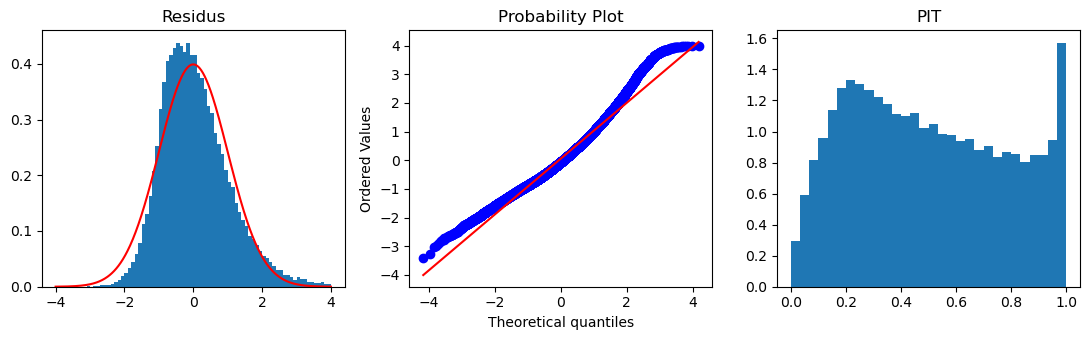

In [166]:
band = "y"
pt.plot_r_stats((mock_cat[f"magnitude_{band}"]-mock_cat[f"magnitude_{band}_true"])/mock_cat[f"magnitude_{band}_err_sim"], rrange=(-4,4))

## **3. Run PhotoZ**

### 3.1 Prepare

In [167]:
#--- Run if no Ids in your table ---
def add_ids(df, base_id):
    n = len(df)
    width = len(str(n-1))
    df.insert(0, "mock_id", 0)
    df["mock_id"] = str(base_id) + pd.Series(range(n)).astype(str).str.zfill(width)
    
    return df

cat_path = f"{base_dir}/{local_dir}/{test_name}_mock.csv"
temp = pd.read_csv(cat_path)
temp = add_ids(temp, 123456)
temp.to_csv(cat_path, index=False)

#--- Transfrom csv formated catalog to .dat, valid for lephare ---
csv_in = f"{base_dir}/{local_dir}/{test_name}_mock.csv"
dat_out = f"{base_dir}/{local_dir}/{test_name}_mock.dat"

#--- csv cols to use. To be set in right order ---
input_columns = ['mock_id', 
    'magnitude_u', 'magnitude_g', 'magnitude_r', 'magnitude_i', 'magnitude_z', 'magnitude_y',
    'magnitude_u_err_sim', 'magnitude_g_err_sim', 'magnitude_r_err_sim', 'magnitude_i_err_sim', 'magnitude_z_err_sim', 'magnitude_y_err_sim']

format_to_lephareinput(CAT_IN=csv_in,
    CAT_OUT=dat_out,
    input_columns=input_columns,
    n_filters=6,
    CAT_TYPE='long', #short = ident + mags +errmags, long += context + zspec
    simple_convert=False,
    apply_context = 'yes', #compute lephare context from non-valid columns
    facticious_specz = 0., #add/replace same specz value for all source
    shuffle=False,
    max_rows=None,
    error_value_state='default' #If default, nan --> 99
    )

[INFO] Added missing 'context' column automatically.
[INFO] Replacing 5849 missing values with 99.0
[INFO] Added constant spec-z column with value 0.0
[OK] Catalog saved → /home/hallouin/Documents/t_hall/lephare-u-Tototime-sedlib-calibration/calibration/data/tests/bt_spectra_fullBTlib/fullBTlib_mock.dat


In [168]:
config.update({
        "ZPHOTLIB": f"{maglib_prefix}{test_name}",
        "SPEC_OUT": "NO",
        "CAT_IN": dat_out,
        "INP_TYPE": "M",
        "CAT_TYPE": "LONG",
        "CAT_MAG": "AB",
        "PARA_OUT": f"{base_dir}/stargal_output.para",
        "CAT_OUT": f"{base_dir}/{local_dir}/{test_name}_mock.out",
        "AUTO_ADAPT": "NO",
        "PDZ_TYPE": "MIN_ZG",
        "CAT_FMT": "MMEE",
        "ERR_SCALE": 0,
        "SPEC_OUT": "NO",
        "CHI2_OUT": "NO",
        "RM_DISCREPENT": 1e9,
        "STAR_PDF_OUT": f"{base_dir}/{local_dir}/{test_name}"
    })

zphota = lp.PhotoZ(lp.all_types_to_keymap(config))

####################################### 
# PHOTOMETRIC REDSHIFT with OPTIONS   # 
# Config file            : 
# CAT_IN                 : /home/hallouin/Documents/t_hall/lephare-u-Tototime-sedlib-calibration/calibration/data/tests/bt_spectra_fullBTlib/fullBTlib_mock.dat
# CAT_OUT                : /home/hallouin/Documents/t_hall/lephare-u-Tototime-sedlib-calibration/calibration/data/tests/bt_spectra_fullBTlib/fullBTlib_mock.out
# CAT_LINES              : 0 1000000000
# PARA_OUT               : /home/hallouin/Documents/t_hall/lephare-u-Tototime-sedlib-calibration/calibration/stargal_output.para
# INP_TYPE               : M
# CAT_FMT[0:MEME 1:MMEE] : 1
# CAT_MAG                : AB
# ZPHOTLIB               : BT_LSST_fullBTlib 
# FIR_LIB                : 
# FIR_LMIN               : 7.000000
# FIR_CONT               : -1.000000
# FIR_SCALE              : -1.000000
# FIR_FREESCALE          : YES
# FIR_SUBSTELLAR         : NO
# ERR_SCALE              : 0.000000 
# ERR_FACTOR             : 1.00

### 3.2 Run

In [169]:
#--- Prepare ---
cat = np.loadtxt(dat_out)
id = cat[:, 0]
mag = cat[:, 1:7]
emag = cat[:, 7:13]
context = cat[:, 13]
zspec = cat[:, 14]
srclist = []

max_row_lephare = 10000
n = np.min((len(cat), max_row_lephare))
for i in range(n):
    oneObj = lp.onesource(i, zphota.gridz)
    oneObj.readsource(str(id[i]), mag[i, :], emag[i, :], int(context[i]), zspec[i], " ")
    zphota.prep_data(oneObj)
    srclist.append(oneObj)

#--- Run ---
zphota.run_photoz(srclist[:n], [0,0,0,0,0,0])
final = zphota.build_output_tables(srclist[:n], filename=f"{base_dir}/{local_dir}/{test_name}_mock.fits")

#--- Convert to pandas ---
t = final.copy()

for col in t.colnames:
    if len(t[col].shape) > 1:
        arr = t[col]
        for i in range(arr.shape[1]):
            t[f"{col}_{i}"] = arr[:, i]
        t.remove_column(col)

final = t.to_pandas()

# Add related physical quantities to table
final = dm.join_tables(final, (sed_grid, "MOD_STAR", "model"))

In [170]:
final.head(3)

,MOD_STAR,IDENT,Z_BEST,Z_MED,Z_MODE,CHI_BEST,MOD_BEST,SCALE_BEST,NBAND_USED,Z_SEC,...,ERR_MAG_OBS()_2,ERR_MAG_OBS()_3,ERR_MAG_OBS()_4,ERR_MAG_OBS()_5,PDF_MIN_ZG()_0,PDF_MIN_ZG()_1,model,teff,logg,feh
0,32,12345600000.0,-99.9,-99.9,0.0,1.000000e+09,-99,-99.000000,6,-99.9,...,0.03423,0.02845,0.05448,0.26855,0.0,0.0,32.0,4000.0,4.5,0.0
1,32,12345600001.0,-99.9,-99.9,0.0,1.000000e+09,-99,0.000000,6,-99.9,...,0.00908,0.01229,0.01480,0.05809,0.0,0.0,32.0,4000.0,4.5,0.0
2,32,12345600002.0,-99.9,-99.9,0.0,1.000000e+09,-99,-20.261044,6,-99.9,...,0.00477,0.00431,0.00609,0.02919,0.0,0.0,32.0,4000.0,4.5,0.0


### 3.3 Cleaning Files

In [171]:
if clean_seds == True:
    sed_grid_path = f'{base_dir}/{local_dir}/{list_name}.list'
    with open(sed_grid_path, 'r') as file:
                for line in file:
                    line = line.strip()
                    if line.startswith('#') or not line:
                        continue
                    file_path = line.split()[0]
                    print(file_path)
                    os.remove(file_path)

if clean_cache == True:
    sedlib_path = f'{cache_dir}/lib_bin/{sedlib_prefix}{test_name}'
    maglib_path = f'{cache_dir}/lib_mag/{maglib_prefix}{test_name}'
    ends = [".bin", ".dat", ".doc"]
    for end in ends:
        for path in [sedlib_path, maglib_path]:
            if os.path.isfile(f"{path}{end}"):
                os.remove(f"{path}{end}")

## **4. Statistics**

### 4.1 $\chi^2$

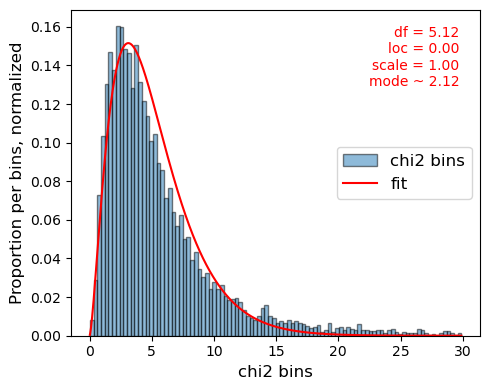

In [172]:
#--- Supposing a Chi2 dsitribution of the fitting parameter, compute the df of this distribution ---
%matplotlib inline
import scipy.stats as stats

# fitting dist
chi_star = final[(final["NBAND_USED"]==6) & (final["SCALE_STAR"]>1e-30)]["CHI_STAR"]
chi_star = chi_star[chi_star<30]

df, loc, scale = stats.chi2.fit(chi_star, floc=0, fscale=1.0)
x = np.linspace(min(chi_star), max(chi_star), 1000)
pdf = stats.chi2.pdf(x, df, loc, scale)

# plot
plt.figure(figsize=(5,4))
hst =plt.hist(chi_star, bins=100, density=True, alpha=0.5, edgecolor='black', label='chi2 bins')
plt.plot(x, pdf, 'r-', label='fit')

# add fit values
plt.text(0.95, 0.95,
    f"df = {df:.2f}\nloc = {loc:.2f}\nscale = {scale:.2f}\nmode ~ {hst[1][np.argmax(hst[0])]:.2f}",
    transform=plt.gca().transAxes,
    verticalalignment='top',
    horizontalalignment='right',
    c='r')

# plt.ylim(0,1)
plt.xlabel("chi2 bins", fontsize = 12)
plt.ylabel("Proportion per bins, normalized", fontsize = 12)
plt.legend(fontsize = 12)
plt.tight_layout()
plt.show()


### 4.2 Physical Quantity

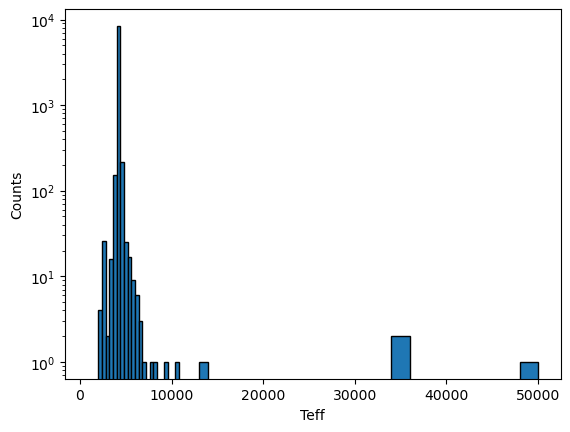

In [173]:
mask = (final["NBAND_USED"]==6) & (final["SCALE_STAR"]>1e-30)
beans = teff_values
plt.figure()
plt.hist(final[mask]["teff"],bins=beans,edgecolor='black',density=False,log=True)
plt.xlabel("Teff")
plt.ylabel("Counts")
plt.show()

We can notice the saturation at the upper boundarie (50000K) but not at the lower boundarie

Load Teff pdfs

In [174]:
# Load pdf file
star_pdfs_file = np.loadtxt(f"{base_dir}/{local_dir}/{test_name}_PDFstar.prob")

# Keep only masked values
final_masked = final#[(final["teff"]>15000) & (final["NBAND_USED"]==6)]
mask = np.isin(star_pdfs_file[:, 0], final_masked["IDENT"].values.astype(float).astype(int))
star_pdfs_file = star_pdfs_file[mask]

# Retrieve PDFs
star_pdfs = star_pdfs_file[:,1:]

# Set in teff increasing order
order = sed_grid.sort_values("teff").index
star_pdfs = star_pdfs[:, order]

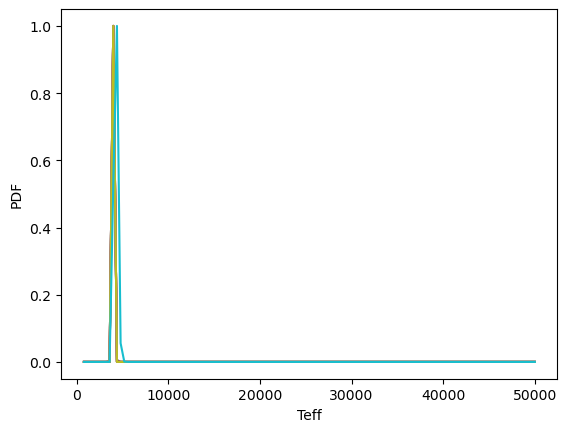

In [175]:
#--- plot pdfs ---
# %matplotlib widget
plt.figure()
for i in range(10):
    # plt.plot(teff_values, star_pdfs[i]/max(star_pdfs[i]))
    plt.plot(teff_values, np.exp(-1/2*(star_pdfs[i]-min(star_pdfs[i]))))

# plt.plot(teff_values, np.exp(-1/2*(star_pdfs[783]-min(star_pdfs[783]))))
# plt.plot(teff_values, star_pdfs[783]/max(star_pdfs[783]))
plt.xlabel("Teff")
plt.ylabel("PDF")
plt.show()

### 4.3 Normalization factor

Reminder: $\alpha = \frac{\sum_i \frac{f_{obs,i}*f_{mod,i}}{\sigma_i}}{\sum_i \frac{f_{mod,i}*f_{mod,i}}{\sigma_i}}$

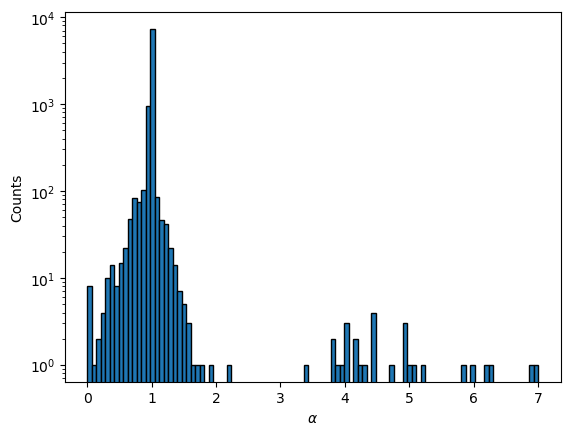

In [176]:
# %matplotlib widget
beans = teff_values
plt.figure()
plt.hist(final[final["NBAND_USED"]==6]["SCALE_STAR"],bins=100,edgecolor='black',density=False,log=True)
plt.xlabel(r"$\alpha$")
plt.ylabel("Counts")
plt.show()

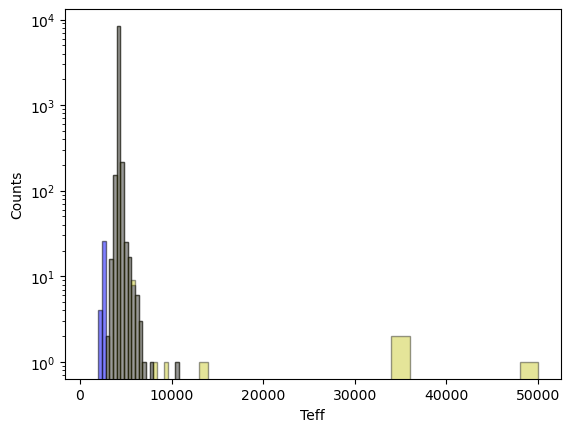

In [177]:
beans = teff_values
plt.figure()

plt.hist(final[(final["NBAND_USED"]==6) & (final["SCALE_STAR"]>0.06)]["teff"], # without very low scale factor
                bins=beans, color='b', edgecolor='black',density=False,log=True, alpha=0.5)
plt.hist(final[(final["NBAND_USED"]==6) & (final["SCALE_STAR"]<2)]["teff"], # without very high scale factor
                bins=beans, color='y',edgecolor='black',density=False,log=True, alpha=0.4)

plt.xlabel("Teff")
plt.ylabel("Counts")
plt.show()

We can see that high scale factors are related to lower Teff and low scale factor are correlated to higher Teff.

In [178]:
bads = final[(final["NBAND_USED"]==6) & (final["SCALE_STAR"]<0.06) | (final["SCALE_STAR"]>2)][
    ["MAG_OBS()_0", "MAG_OBS()_1","MAG_OBS()_2","MAG_OBS()_3","MAG_OBS()_4","MAG_OBS()_5",
    "ERR_MAG_OBS()_0","ERR_MAG_OBS()_1","ERR_MAG_OBS()_2", "ERR_MAG_OBS()_3", "ERR_MAG_OBS()_4", "ERR_MAG_OBS()_5"]
]

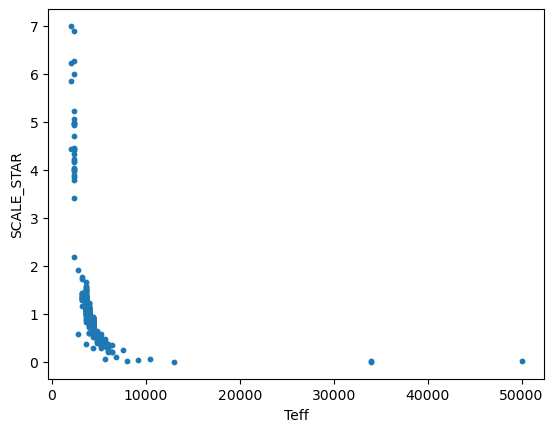

In [181]:
mask = (final["NBAND_USED"]==6) & (final["SCALE_STAR"]>1e-30) & (final["MAG_OBS()_0"]<99)
plt.figure()
plt.scatter(final[mask]["teff"], final[mask]["SCALE_STAR"], s=10)

plt.xlabel("Teff")
plt.ylabel("SCALE_STAR")
plt.show()

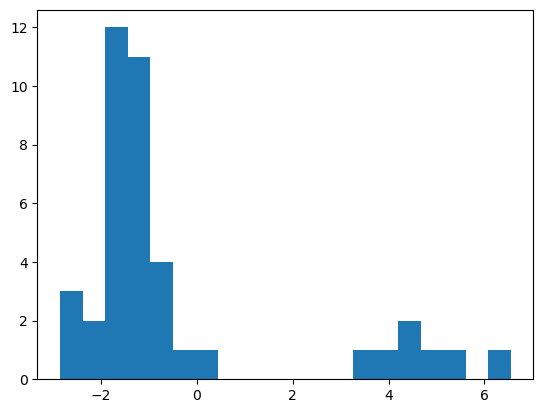

In [180]:
band = 5
plt.figure()
plt.hist(bads[bads[f"MAG_OBS()_{band}"] < 99][f"MAG_OBS()_{band}"] , bins=20)
plt.show()